In [1]:
import os
import numpy as np
import cv2
from PIL import Image
from matplotlib import pyplot as plt

In [2]:
pmatrix_new = np.load('./data/pmatrix_new.npy')
new_w = int(np.load('./data/new_w.npy'))
new_h = int(np.load('./data/new_h.npy'))

coord [80843700, 80851400, 80858100, 80864700, 80872600, 80881300, 80890500, 80899200, 80907700, 80919100, 80933800, 80949400, 80964800, 80977300, 80987000, 80995000, 81002100, 81009500, 81016600, 81023900, 81031300, 81038400, 81044800, 81050700, 81057100, 81063700, 81070000, 81077700, 81085300, 81092500, 81099100, 81105600, 81112600, 81120800, 81129400, 81138400, 81148100, 81157500, 81166100, 81173700, 81183100, 81194800, 81205100, 81215000, 81225500, 81236100, 81249800, 81260900, 81269900, 81278800, 81290100, 81300700, 81310300, 81321700, 81332500, 81341700, 81351300, 81361000, 81372400, 81382400, 81392700, 81405100, 81422100, 81441700, 81457100, 81470400]
(28522, 14268)


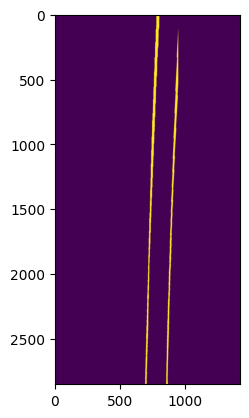

In [3]:
src = r'./data/3/masks'
img_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.jpg')]
msk_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.npy')]

import re
coord = []

msk_fs = msk_fs[:66]  # временно для тестов

for f in msk_fs:
    match = re.search(r'(\d+\.\d)', f)
    if match:
        result = match.group(1)
        coord.append(int(float(result)*1000))  # переводим координаты в мм

print('coord', coord)


def load_warp(mask_path):
    mask = np.load(mask_path)
    mask = np.array(mask, dtype=np.uint8)
    res = cv2.warpPerspective(mask, pmatrix_new, (new_w, new_h))
    res[:, :int(res.shape[1]/3)] = 0
    res[:, -int(res.shape[1]/3):] = 0
    return res

def resize(arr):
    # scale = 1000 / max(arr.shape)
    scale = 0.1
    display_res = cv2.resize(arr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return display_res

# fig, ax = plt.subplots()

# # mask_pr = load_warp(r"D:\Projects\perspective\data\3\080843.789.jpg")
mask_pr = load_warp(msk_fs[20])

print(mask_pr.shape)
plt.imshow(resize(mask_pr))

In [4]:
def bend(mask, shift=200):
    h, w = mask.shape[:2]
    # Исходные углы (порядок: верх-лево, верх-право, низ-право, низ-лево)
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])

    dst = np.float32([
        [shift, 0],        # верх-лево → вправо
        [w + shift, 0],    # верх-право → влево
        [w, h],            # низ-право — на месте
        [0, h]             # низ-лево — на месте
    ])
    # Матрица и преобразование
    M = cv2.getPerspectiveTransform(src, dst)
    result = cv2.warpPerspective(mask, M, (w, h))
    return result

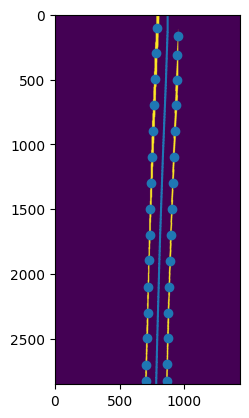

In [5]:
def find_rail_dots(mask, step=2000):
    # далее можно сократить расчеты
    """[Y, X] для рельсов, [y_centr, x_centr] для центр точек"""
    centroids = []

    height = mask.shape[0]
    num_steps = int(np.ceil(height / step))

    for i in range(num_steps):
        st = i * step
        en = np.min((st + step, height))
        contours, _ = cv2.findContours(mask[st:en, :], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        for contour in contours:
            M = cv2.moments(contour)
            if M["m00"] != 0:  # Проверяем, чтобы избежать деления на ноль
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                centroids.append((cx, cy+st))

    X = np.array(centroids)[:, 0]
    Y = np.array(centroids)[:, 1]
    diff = np.diff(Y)
    # ищет пары близких центроидов (где вертикальное расстояние меньше 3 пикселей) и вычисляет для них среднюю точку по X

    mid_p = []
    for i, v in enumerate(diff):
        if v < 3:
            mid_x = int((X[i] + X[i+1]) / 2)
            mid_y = int((Y[i] + Y[i+1]) / 2)
            mid_p.append([mid_x, mid_y])

    mid_p = np.array(mid_p) # точки между центроидами
    # Интеролировать серединки для всех У
    y_centr = np.arange(mask.shape[0])
    x_centr = np.interp(y_centr, mid_p[:, 1], mid_p[:, 0])

    return np.array([Y, X]), np.array([y_centr, x_centr])


YX, yx_centr = find_rail_dots(mask_pr)

plt.imshow(resize(mask_pr))
plt.scatter(YX[1, :]//10, YX[0, :]//10)
plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
plt.margins(0, 0)


./data/3/masks\080843.789.npy


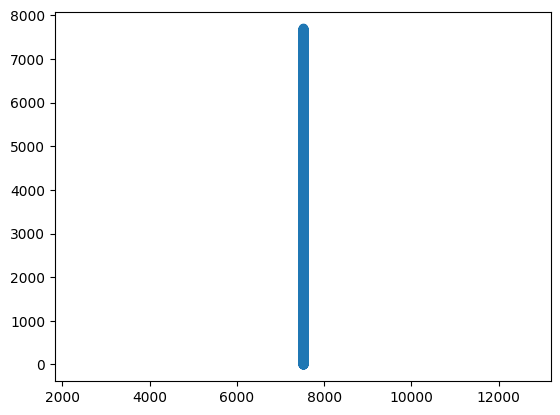

In [ ]:
# цикл обработки
# сохранит оси

Array = np.zeros((1, 2))

coef = 0
c1_up = 0
for i, (m_f, c) in enumerate(zip(msk_fs[:1], coord[:1])):  # 13:14
    mask = load_warp(m_f)
    print(m_f)
    mask = mask[-(coord[i+1] - coord[i]): -1, :]  # взять низ маски по коорд

    # mask = bend(mask, shift=200)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=900)
    # plt.imshow(resize(mask))
    # plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
    # plt.show()
    c2_dwn = yx_centr[1][-1]  # низ текущего коорд_кадра по х
    if not coef:  # для первой итерации
        shift = 0
    else:
        shift = c2_dwn - c1_up

    # коррекция оси
    yx_centr[1] -= shift # сдвинуть все иксы
    yx_centr[0] += coef # сдвинуть все у
    # верх коорд_кадра по х
    c1_up = yx_centr[1][0]
    # к текущ координатам (y) от 0 прибавляем проеханное
    coef += len(yx_centr[0])

    # преобразовать ось у. Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _x = yx_centr[:, 0]
    _x = _x[::-1]
    yx_centr[:, 0] = _x

    Array = np.vstack((Array, yx_centr))
Array = Array[1:, :]  # убир перв строка, кот 0 0

plt.scatter(Array[:, 1], Array[:, 0])
plt.axis('equal')
plt.show()


In [ ]:
plt.scatter(Array[:, 1], Array[:, 0])
plt.axis('equal')
plt.show()

In [173]:
# поворот

def rotate(rect, angle, point):
    """angle в радианах
       point точка вокруг которой повернуть
    """
    c, s = np.cos(angle), np.sin(angle)
    rotation_matrix = np.array([
        [c, -s],
        [s,  c]
    ])

    shifted_rect = rect - point
    rotated_rectangle = (rotation_matrix @ shifted_rect.T).T + point
    return rotated_rectangle


# проверка
# rect = np.array([[100, 0],
#                 [150, 0],
#                 [150, 180],
#                 [100, 180]])

# point = np.array([0, 0])
# rotated_rectangle = rotate(rect, -1.56, point)

# plt.scatter(rect[:, 0], rect[:, 1])
# plt.scatter(rotated_rectangle[:, 0], rotated_rectangle[:, 1])
# plt.axis('equal')

[[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
  18. 19.]
 [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  2.  3.
   4.  5.]]
[[20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 37.
  38. 39.]
 [ 5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.
   5.  5.]]
[0. 1.] [19.  5.]
0.20749622643520266
11.888658039627975


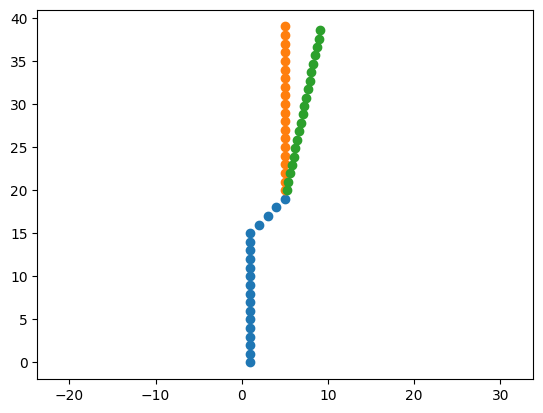

In [ ]:
# [y, x]

a1 = np.array([np.arange(20), np.ones(20)])
a1[1, 15:] += np.arange(5)


a2 = np.array([np.arange(20, 40), np.ones(20)])
a2[1, :] += 4

print(a1)
print(a2)

p1 = a1.T[0]
p2 = a1.T[-1]
print(p1, p2)

dx = p2[0] - p1[0]
dy = p2[1] - p1[1]

angle = np.arctan2(dy, dx)
print(angle)
angle_deg = np.degrees(angle)
print(angle_deg)

a3 = rotate(a2.T, angle, p2)


plt.scatter(a1[1, :], a1[0, :])
plt.scatter(a2[1, :], a2[0, :])
plt.scatter(a3.T[1, :], a3.T[0, :])
plt.axis('equal');

[1. 0.] [ 5. 19.]
0.20749622643520266
11.888658039627975


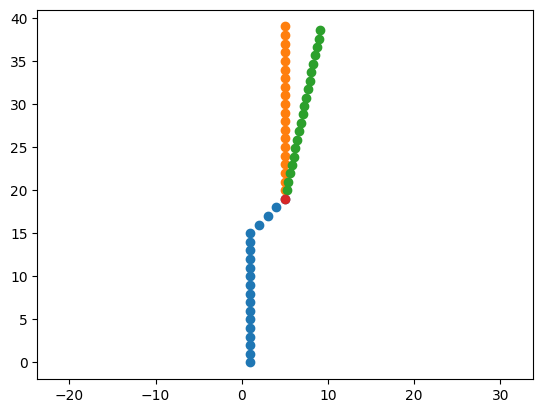

In [206]:
# пример вращения
# [x, y]

a1 = np.array([np.ones(20), np.arange(20)])
a1[0, 15:] += np.arange(5)


a2 = np.array([np.ones(20), np.arange(20, 40)])
a2[0, :] += 4

p1 = a1.T[0]
p2 = a1.T[-1]
print(p1, p2)

dx = p2[0] - p1[0]
dy = p2[1] - p1[1]


# input: y-coordinates, x-coordinates
angle = np.arctan2(dx, dy)
print(angle)
angle_deg = np.degrees(angle)
print(angle_deg)

a3 = rotate(a2.T, -angle, p2)


plt.scatter(a1[0, :], a1[1, :])
plt.scatter(a2[0, :], a2[1, :])
plt.scatter(a3.T[0, :], a3.T[1, :])
plt.scatter(p2[0], p2[1])
plt.axis('equal');


In [181]:
p2

array([ 5., 19.])

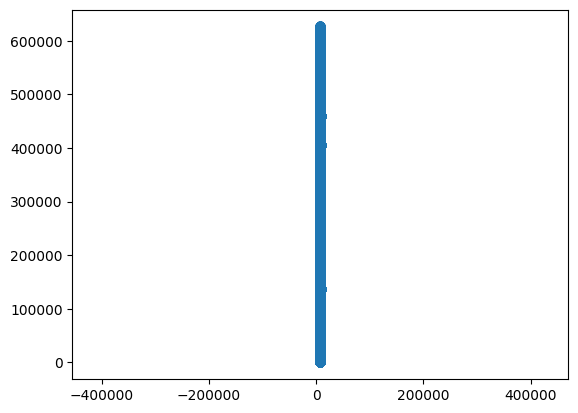

In [ ]:
# цикл обработки
# сохранит оси

Array = np.zeros((1, 2))

coef = 0
c1_up = 0
for i, (m_f, c) in enumerate(zip(msk_fs[:-1], coord[:-1])):  # 13:14
    mask = load_warp(m_f)
    mask = mask[-(coord[i+1] - coord[i]): -1, :]  # взять низ маски по коорд

    # mask = bend(mask, shift=200)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=900)
    # plt.imshow(resize(mask))
    # plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
    # plt.show()
    c2_dwn = yx_centr[1][-1]  # низ текущего коорд_кадра по х
    if not coef:  # для первой итерации
        shift = 0
        angle = 0
    else:
        # сдвиг: нижн_центр текущ - верх_центр предыдущ
        shift = c2_dwn - c1_up

    # коррекция осей
    yx_centr[1] += shift  # сдвинуть все иксы
    yx_centr[0] += coef  # сдвинуть все у на пройденное в предыдущ коорд

    c1_up = yx_centr[1][0]  # верх коорд_кадра по х
    coef += len(yx_centr[0])

    # преобразовать ось у (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y

    # поворот кривой
    # print(angle)
    if angle:
        # yx_centr = rotate(yx_centr[:, [1, 0]], angle, yx_centr[-1])
        # yx_centr = yx_centr[:, [1, 0]]
    # print(np.int64(yx_centr))
    # break
    # угол для поворота следующей кривой
    # p1, p2 = yx_centr[-1], yx_centr[0]
    # dx = p2[0] - p1[0]
    # dy = p2[1] - p1[1]
    # angle = np.arctan2(dy, dx)
        ...



    Array = np.vstack((Array, yx_centr))
Array = Array[1:, :]  # убир перв строка, кот 0 0

plt.scatter(Array[:, 1], Array[:, 0])
plt.axis('equal')
plt.show()


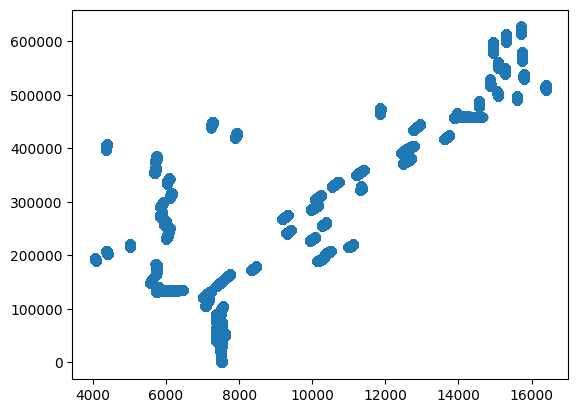

In [92]:
plt.scatter(Array[:, 1], Array[:, 0])
# plt.axis('equal')
plt.show()

In [85]:
dx = p2[0] - p1[0]
dy = p2[1] - p1[1]

angle = np.arctan2(dy, dx)
angle

np.float64(1.5719654611024276)

In [79]:
p2[0]

np.float64(809.0244529426509)

In [ ]:
yx_centr

array([[ 7707.94452362,  7707.94569275,  7707.94686189, ...,
         7698.77305678,  7698.77422591,  7698.77539504],
       [14589.23964013, 14588.23964081, 14587.2396415 , ...,
         7893.22434115,  7892.22434183,  7891.22434252]])